# Exploratory Data Analysis


In [1]:
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from tqdm.auto import tqdm
from skimage.morphology import dilation, disk

try:
    import nibabel as nib
    HAS_NIBABEL = True
except ImportError:
    HAS_NIBABEL = False
    print('[WARN] nibabel not installed — assuming PNG/JPG files')

from PIL import Image

sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 120

ROOT = Path('../dataset/raw')
TRAIN_IMG_DIR = ROOT / 'train' / 'images'
TRAIN_MSK_DIR = ROOT / 'train' / 'masks'
TEST_IMG_DIR  = ROOT / 'test'  / 'images'
TEST_MSK_DIR  = ROOT / 'test'  / 'masks'

for d in [TRAIN_IMG_DIR, TRAIN_MSK_DIR, TEST_IMG_DIR, TEST_MSK_DIR]:
    status = 'Present ' if d.exists() else 'MISSING ' 
    print(f'{status}  {d}')

[WARN] nibabel not installed — assuming PNG/JPG files
Present   ../dataset/raw/train/images
Present   ../dataset/raw/train/masks
Present   ../dataset/raw/test/images
Present   ../dataset/raw/test/masks


In [2]:
SEED = 42
DISK_RADIUS = 2
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

PLOT_DIR = Path('../plots')
PLOT_DIR.mkdir(parents=True, exist_ok=True)
print(f'PLOT_DIR : {PLOT_DIR.resolve()}')

PLOT_DIR : /home/prabhunotfound/Desktop/Programs/DAC-202/DAC_Project/plots


## File inventory

In [3]:
def list_files(folder: Path) -> list:
    exts = ['*.nii.gz', '*.nii', '*.png', '*.jpg', '*.jpeg', '*.npy']
    files = []
    for ext in exts:
        files.extend(folder.glob(ext))
    return sorted(files)

train_imgs = list_files(TRAIN_IMG_DIR)
train_msks = list_files(TRAIN_MSK_DIR)
test_imgs = list_files(TEST_IMG_DIR)
test_msks = list_files(TEST_MSK_DIR)

print('File Inventory\n')
print(f'Train images : {len(train_imgs)}')
print(f'Train masks  : {len(train_msks)}')
print(f'Test  images : {len(test_imgs)}')
print(f'Test  masks  : {len(test_msks)}')
print(f'Total        : {len(train_imgs) + len(test_imgs)} samples')

assert len(train_imgs) == len(train_msks), 'Train image/mask count mismatch!'
assert len(test_imgs) == len(test_msks),  'Test  image/mask count mismatch!'

print('\nSample filenames (train images):')
for f in train_imgs[:5]:
    print(f'  {f.name}')

print('\nSample filenames (train masks):')
for f in train_msks[:5]:
    print(f'  {f.name}')

File Inventory

Train images : 3933
Train masks  : 3933
Test  images : 860
Test  masks  : 860
Total        : 4793 samples

Sample filenames (train images):
  brisc2025_train_00001_gl_ax_t1.jpg
  brisc2025_train_00002_gl_ax_t1.jpg
  brisc2025_train_00003_gl_ax_t1.jpg
  brisc2025_train_00004_gl_ax_t1.jpg
  brisc2025_train_00005_gl_ax_t1.jpg

Sample filenames (train masks):
  brisc2025_train_00001_gl_ax_t1.png
  brisc2025_train_00002_gl_ax_t1.png
  brisc2025_train_00003_gl_ax_t1.png
  brisc2025_train_00004_gl_ax_t1.png
  brisc2025_train_00005_gl_ax_t1.png


In [4]:
def load_as_numpy(filepath: Path) -> np.ndarray:
    suffix = ''.join(filepath.suffixes).lower()

    if '.nii' in suffix:
        vol = nib.load(str(filepath)).get_fdata().astype(np.float32)
        if vol.ndim == 3:
            vol = vol[:, :, vol.shape[2] // 2]
        return vol

    elif suffix == '.npy':
        return np.load(str(filepath)).astype(np.float32)

    else:
        img = Image.open(filepath).convert('L')
        return np.array(img).astype(np.float32)

sample_img = load_as_numpy(train_imgs[0])
sample_msk = load_as_numpy(train_msks[0])
print(f' Image: shape={sample_img.shape}  dtype = {sample_img.dtype}  '
      f'min={sample_img.min():.1f}  max={sample_img.max():.1f}')
print(f' Mask:  shape={sample_msk.shape}  dtype = {sample_msk.dtype}  '
      f'\n\tUnique Values={np.unique(sample_msk).tolist()}')

 Image: shape=(512, 512)  dtype = float32  min=0.0  max=255.0
 Mask:  shape=(512, 512)  dtype = float32  
	Unique Values=[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 248.0, 249.0, 250.0, 251.0, 252.0, 253.0, 254.0, 255.0]


## Image shape analysis

In [5]:
shapes = []
all_files = train_imgs + test_imgs

for f in all_files:
    arr = load_as_numpy(f)
    shapes.append(arr.shape[:2])

shapes = np.array(shapes)
heights = shapes[:, 0]
widths = shapes[:, 1]

print(' Spatial Dimensions ')
print(f'  Height — min : {heights.min()}  max : {heights.max()}  mean : {heights.mean():.1f}')
print(f'  Width  — min : {widths.min()}  max : {widths.max()}  mean : {widths.mean():.1f}')

unique_shapes = np.unique(shapes, axis=0)
print(f'\n  Unique (H, W) combinations: {len(unique_shapes)}')
for s in unique_shapes:
    count = (shapes == s).all(axis=1).sum()
    print(f'    {s[0]} x {s[1]}  ->  {count} files')

 Spatial Dimensions 
  Height — min : 195  max : 1427  mean : 502.3
  Width  — min : 174  max : 1365  mean : 501.4

  Unique (H, W) combinations: 140
    195 x 314  ->  1 files
    202 x 202  ->  1 files
    207 x 201  ->  2 files
    210 x 201  ->  1 files
    212 x 226  ->  1 files
    212 x 238  ->  2 files
    214 x 226  ->  2 files
    216 x 214  ->  2 files
    216 x 216  ->  2 files
    216 x 224  ->  2 files
    216 x 234  ->  2 files
    218 x 180  ->  1 files
    219 x 224  ->  2 files
    220 x 215  ->  1 files
    221 x 228  ->  2 files
    223 x 200  ->  4 files
    223 x 202  ->  1 files
    223 x 226  ->  1 files
    223 x 229  ->  1 files
    224 x 239  ->  2 files
    225 x 209  ->  1 files
    225 x 225  ->  15 files
    228 x 221  ->  1 files
    230 x 174  ->  1 files
    232 x 217  ->  2 files
    234 x 215  ->  2 files
    234 x 219  ->  2 files
    235 x 200  ->  2 files
    235 x 214  ->  2 files
    236 x 200  ->  1 files
    236 x 213  ->  2 files
    237 x 21

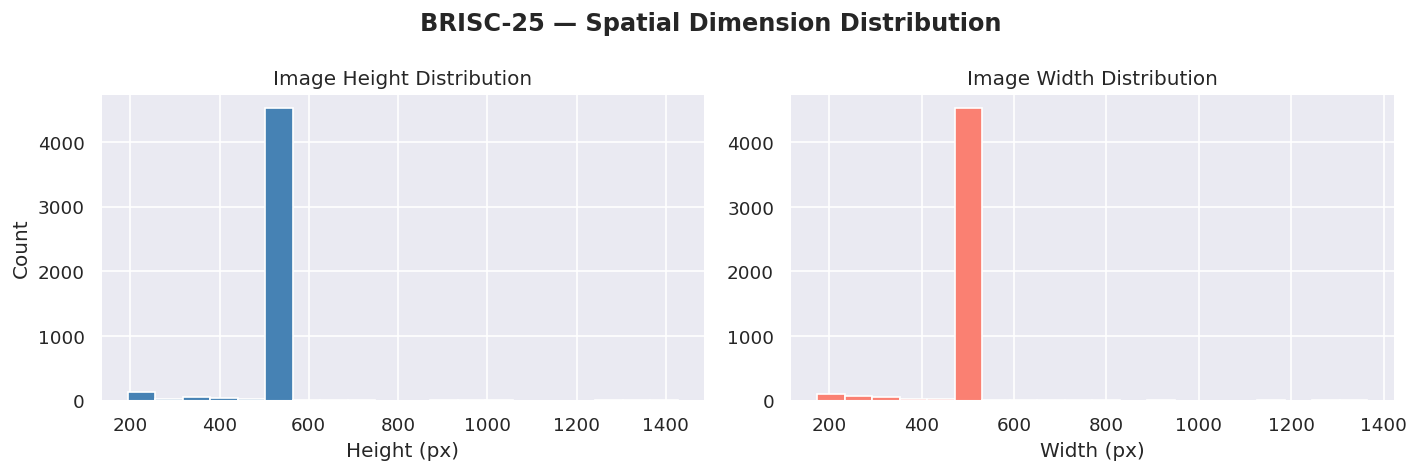

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(heights, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Image Height Distribution')
axes[0].set_xlabel('Height (px)')
axes[0].set_ylabel('Count')

axes[1].hist(widths, bins=20, color='salmon', edgecolor='white')
axes[1].set_title('Image Width Distribution')
axes[1].set_xlabel('Width (px)')

plt.suptitle('BRISC-25 — Spatial Dimension Distribution', fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'eda_shape_distribution.png', bbox_inches='tight')
plt.show()

## Class imbalance (ROI % per image)

In [15]:
roi_ratios = []
empty_masks = 0

all_pairs = list(zip(train_imgs + test_imgs,train_msks + test_msks))
for img_f, msk_f in tqdm(all_pairs, desc='ROI ratios'):
    msk = load_as_numpy(msk_f)
    binary = (msk > 0)
    ratio = binary.sum() / binary.size * 100
    roi_ratios.append(ratio)
    if binary.sum() == 0:
        empty_masks += 1

roi_ratios = np.array(roi_ratios)

print(' Class Imbalance (Foreground %) \n')
print(f'  Mean   : {roi_ratios.mean():2.3f} %')
print(f'  Median : {np.median(roi_ratios):2.3f} %')
print(f'  Min    : {roi_ratios.min():2.3f} %')
print(f'  Max    : {roi_ratios.max():2.2f} %')
print(f'  Std    : {roi_ratios.std():2.3f} %')
print(f'\n  Empty masks (0% ROI) : {empty_masks}')
extreme = (roi_ratios < 2).sum()
print(f'  Masks with ROI < 2% : {extreme}')

ROI ratios:   0%|          | 0/4793 [00:00<?, ?it/s]

 Class Imbalance (Foreground %) 

  Mean   : 1.885 %
  Median : 1.429 %
  Min    : 0.041 %
  Max    : 19.61 %
  Std    : 1.594 %

  Empty masks (0% ROI) : 0
  Masks with ROI < 2% : 3213


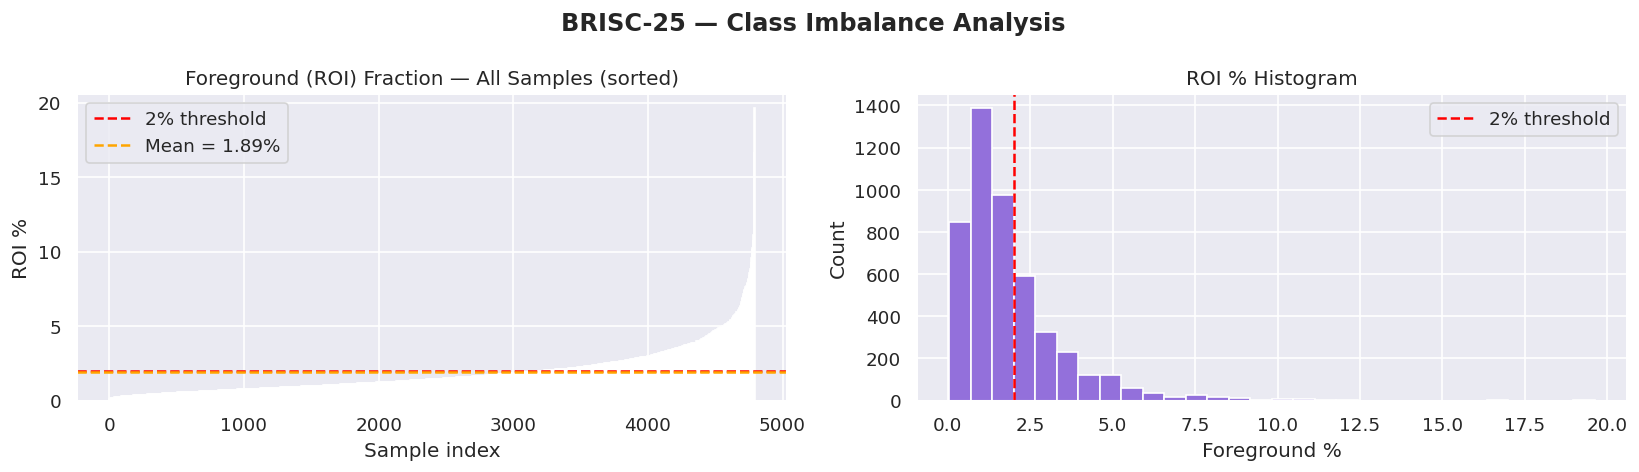

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(len(roi_ratios)), sorted(roi_ratios), color='blue', width=1.0)
axes[0].axhline(2,color='red',linestyle='--', lw=1.5, label='2% threshold')
axes[0].axhline(roi_ratios.mean(), color='orange', linestyle='--', lw=1.5, label=f'Mean = {roi_ratios.mean():.2f}%')
axes[0].set_title('Foreground (ROI) Fraction — All Samples (sorted)')
axes[0].set_xlabel('Sample index')
axes[0].set_ylabel('ROI %')
axes[0].legend()

axes[1].hist(roi_ratios, bins=30, color='mediumpurple', edgecolor='white')
axes[1].axvline(2, color='red', linestyle='--', lw=1.5, label='2% threshold')
axes[1].set_title('ROI % Histogram')
axes[1].set_xlabel('Foreground %')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('BRISC-25 — Class Imbalance Analysis', fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'eda_class_imbalance.png', bbox_inches='tight')
plt.show()

## Intensity distribution

In [9]:
intensities = []
sample_files = (train_imgs + test_imgs)[:20]

for f in tqdm(sample_files, desc='Sampling intensities'):
    arr = load_as_numpy(f).flatten()
    brain = arr[arr > 0]
    if len(brain) > 0:
        idx = np.random.choice(len(brain), min(10000, len(brain)), replace=False)
        intensities.extend(brain[idx].tolist())

intensities = np.array(intensities)
print(f'Sampled {len(intensities):,} brain voxels from {len(sample_files)} images\n')
print(f'Intensity range : {intensities.min():.2f} – {intensities.max():.2f}')
print(f'Mean            : {intensities.mean():.2f}')
print(f'Std             : {intensities.std():.2f}')
print(f'Median          : {np.median(intensities):.2f}')

Sampling intensities:   0%|          | 0/20 [00:00<?, ?it/s]

Sampled 200,000 brain voxels from 20 images

Intensity range : 1.00 – 253.00
Mean            : 39.22
Std             : 39.16
Median          : 39.00


Per-image stats:   0%|          | 0/4793 [00:00<?, ?it/s]

/tmp/ipykernel_22335/3959033416.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([per_img_means, per_img_stds],labels=['Per-image Mean', 'Per-image Std'],patch_artist=True,boxprops=dict(facecolor='lightcoral'))


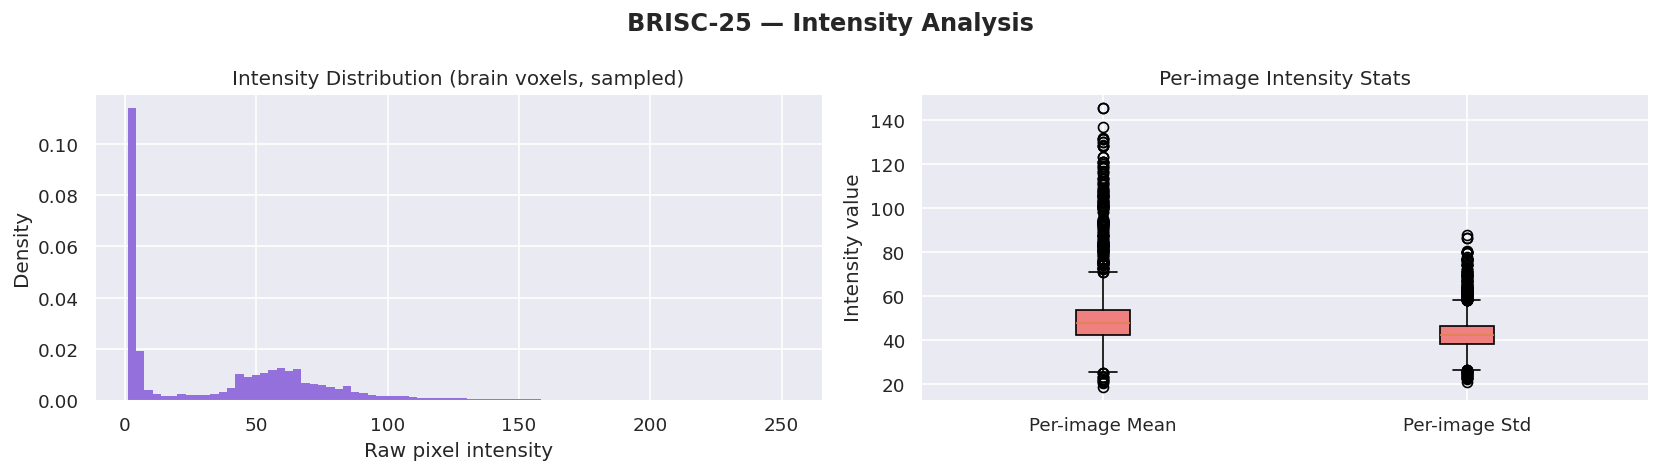

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(intensities, bins=80, color='mediumpurple', edgecolor='none', density=True)
axes[0].set_title('Intensity Distribution (brain voxels, sampled)')
axes[0].set_xlabel('Raw pixel intensity')
axes[0].set_ylabel('Density')

per_img_means = []
per_img_stds = []
for f in tqdm(train_imgs + test_imgs, desc='Per-image stats'):
    arr = load_as_numpy(f).flatten()
    brain = arr[arr > 0]
    if len(brain) > 0:
        per_img_means.append(brain.mean())
        per_img_stds.append(brain.std())

axes[1].boxplot([per_img_means, per_img_stds],labels=['Per-image Mean', 'Per-image Std'],patch_artist=True,boxprops=dict(facecolor='lightcoral'))
axes[1].set_title('Per-image Intensity Stats')
axes[1].set_ylabel('Intensity value')

plt.suptitle('BRISC-25 — Intensity Analysis', fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'eda_intensity_distribution.png', bbox_inches='tight')
plt.show()

## Sample visualization: image + mask overlay

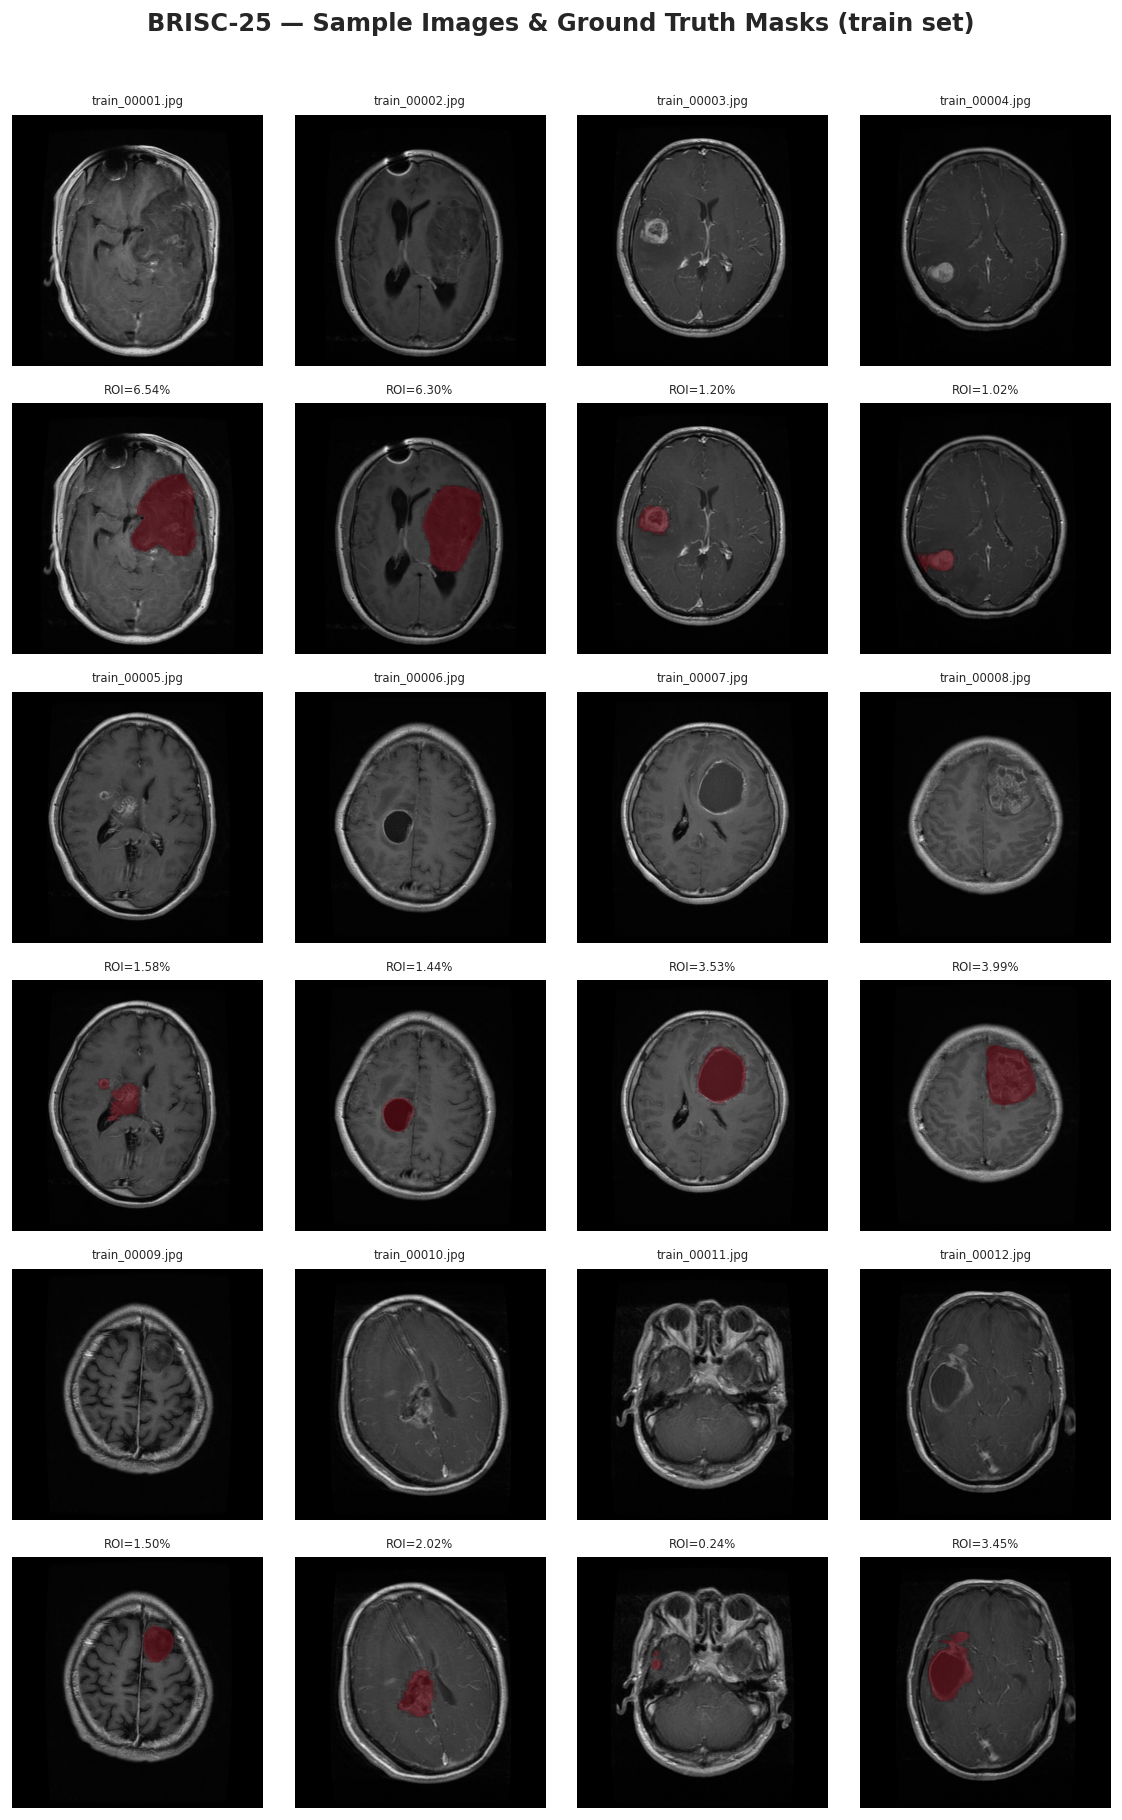

In [11]:
N_SHOW = 12
N_COLS = 4
N_ROWS = (N_SHOW + N_COLS - 1) // N_COLS

fig, axes = plt.subplots(N_ROWS * 2, N_COLS, figsize=(N_COLS * 2.4, N_ROWS * 5))
sample_pairs = list(zip(train_imgs, train_msks))[:N_SHOW]

for idx, (img_f, msk_f) in enumerate(sample_pairs):
    row = (idx // N_COLS) * 2
    col = idx % N_COLS
    img = load_as_numpy(img_f)
    msk = load_as_numpy(msk_f)
    roi_pct = (msk > 0).mean() * 100

    axes[row, col].imshow(img, cmap='gray')
    axes[row, col].set_title(img_f.name.replace('brisc2025_', '').replace('_gl_ax_t1', '')[:16], fontsize=7)
    axes[row, col].axis('off')

    axes[row+1,col].imshow(img, cmap='gray')
    axes[row+1,col].imshow(np.ma.masked_where(msk == 0, msk),cmap='Reds', alpha=0.55, vmin=0, vmax=1)
    axes[row+1,col].set_title(f'ROI={roi_pct:.2f}%', fontsize=7)
    axes[row+1,col].axis('off')

for idx in range(N_SHOW, N_ROWS * N_COLS):
    row = (idx // N_COLS) * 2
    col = idx % N_COLS
    axes[row,col].axis('off')
    axes[row+1,col].axis('off')

plt.suptitle('BRISC-25 — Sample Images & Ground Truth Masks (train set)',fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'eda_sample_grid.png', bbox_inches='tight')
plt.show()

## Tumour area statistics


In [12]:
def pixel_ratio(mask_path: Path) -> float:
    m = load_as_numpy(mask_path)
    return float((m > 0).sum() / m.size)
train_set = set(train_imgs)  
records = []
for img_f, msk_f in tqdm(list(zip(train_imgs + test_imgs,train_msks + test_msks)),desc='pixel ratios'):
    records.append({'filename' : img_f.name,'split' : 'train' if img_f in train_set else 'test','pixel_ratio' : pixel_ratio(msk_f),})

df_area = pd.DataFrame(records)

print('Tumour Area Fraction — overall\n')
print(df_area['pixel_ratio'].describe().round(5).to_string())
print()
print('By Split \n')
print(df_area.groupby('split')['pixel_ratio'].agg(['mean','median','min','max','std']).round(5).to_string())

pixel ratios:   0%|          | 0/4793 [00:00<?, ?it/s]

Tumour Area Fraction — overall

count    4793.00000
mean        0.01885
std         0.01595
min         0.00041
25%         0.00840
50%         0.01429
75%         0.02364
max         0.19609

By Split 

          mean   median      min      max      std
split                                             
test   0.02115  0.01416  0.00127  0.16700  0.02034
train  0.01835  0.01438  0.00041  0.19609  0.01477


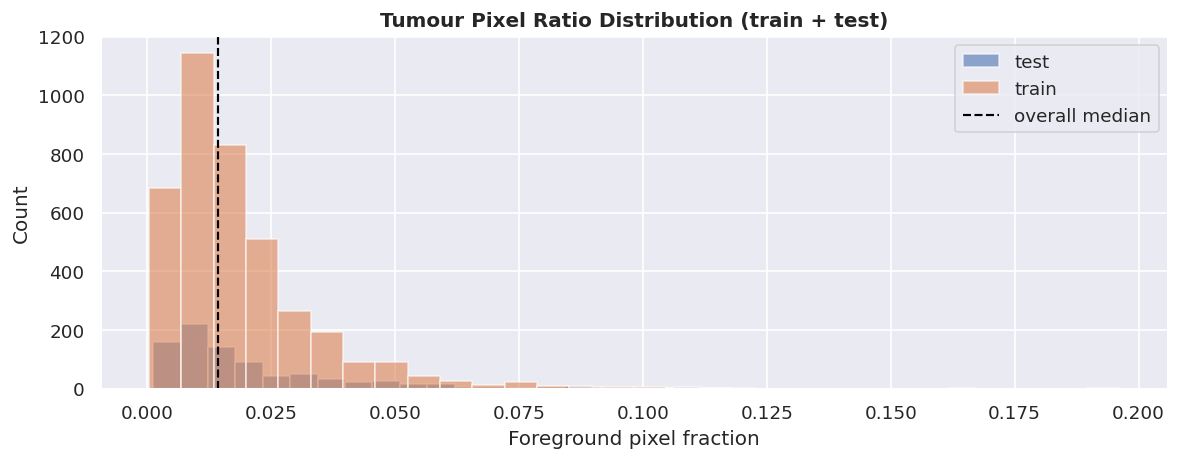

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))

for split, grp in df_area.groupby('split'):
    ax.hist(grp['pixel_ratio'], bins=30, alpha=0.6, label=split)

ax.axvline(df_area['pixel_ratio'].median(), color='black',linestyle='--', linewidth=1.3, label='overall median')
ax.set_title('Tumour Pixel Ratio Distribution (train + test)', fontweight='bold')
ax.set_xlabel('Foreground pixel fraction')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / 'eda_pixel_ratio_dist.png', dpi=150, bbox_inches='tight')
plt.show()

##  Boundary map visualization (MRI | Mask | Boundary)


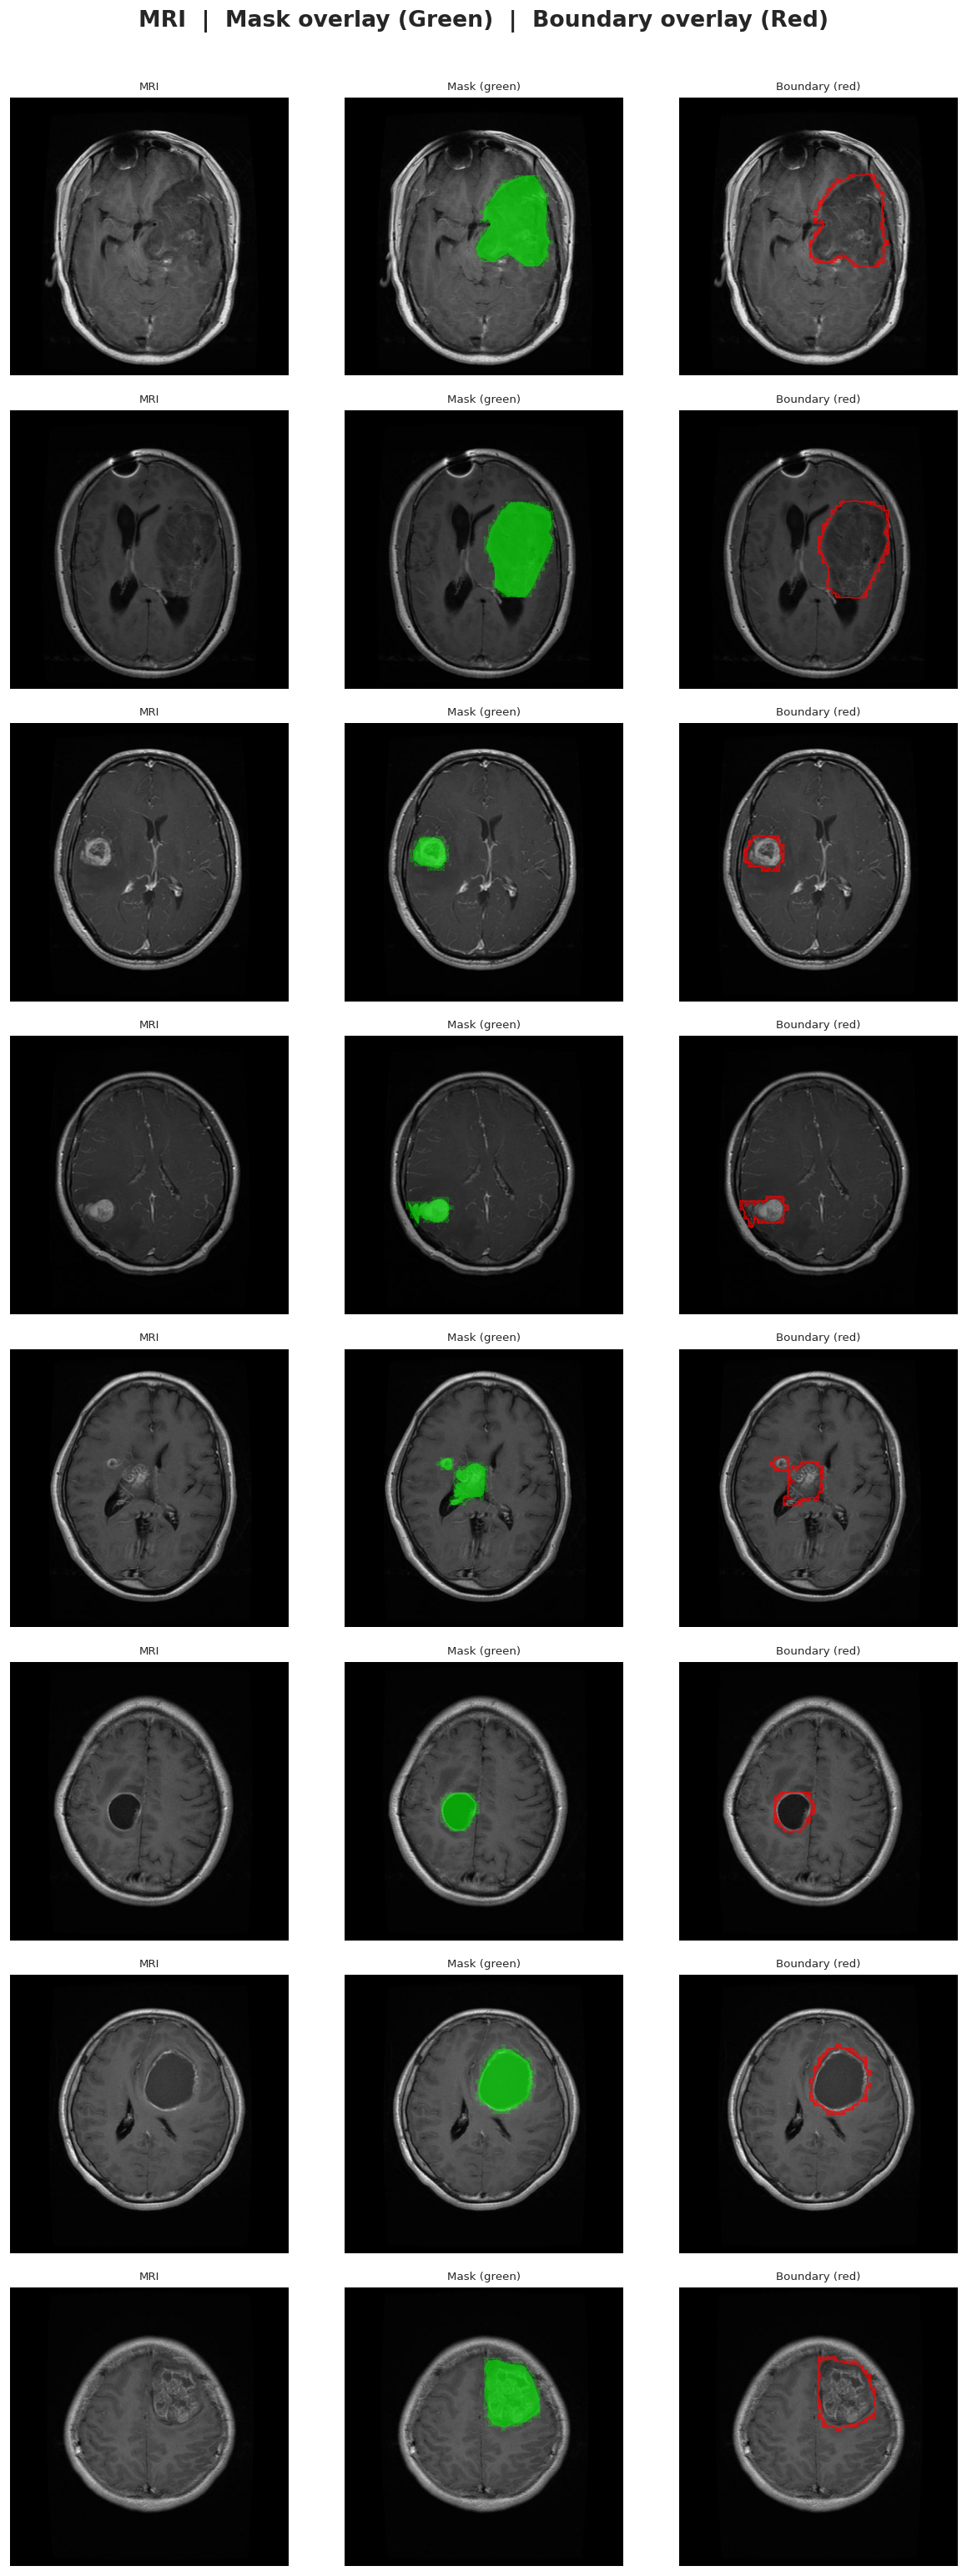

In [ ]:
def compute_boundary_map(mask_array: np.ndarray) -> np.ndarray:
    binary = (mask_array > 0).astype(np.uint8)
    dilated = dilation(binary, disk(DISK_RADIUS))
    boundary = (dilated.astype(int) - binary.astype(int)) > 0
    return boundary.astype(np.float32)

non_empty_pairs = [(i, m) for i, m in zip(train_imgs, train_msks) if (load_as_numpy(m) > 0).any()]
samples = non_empty_pairs[:8]

N_ROWS, N_COLS = len(samples), 3
fig, axes = plt.subplots(N_ROWS, N_COLS,figsize=(N_COLS * 3.5, N_ROWS * 3.2))
fig.suptitle('MRI  |  Mask overlay (Green)  |  Boundary overlay (Red)',fontsize=16, fontweight='bold', y=1.005)

for row, (img_f, msk_f) in enumerate(samples):
    img = load_as_numpy(img_f)
    mask = load_as_numpy(msk_f)
    binary = (mask > 0).astype(np.uint8)
    bmap = compute_boundary_map(mask)

    lo, hi = img.min(), img.max()
    img_u8 = ((img - lo) / (hi - lo + 1e-8) * 255).astype(np.uint8)

    axes[row, 0].imshow(img_u8, cmap='gray')
    short = img_f.name.replace('brisc2025_','').replace('_gl_ax_t1','')[:14]
    axes[row, 0].set_ylabel(short, fontsize=7, rotation=0, labelpad=58, va='center')

    rgb = np.stack([img_u8]*3, axis=-1).astype(float)
    px = binary > 0
    rgb[px,0] *= 0.4
    rgb[px,1] = rgb[px,1]*0.4 + 0.6*255
    rgb[px,2] *= 0.4
    axes[row, 1].imshow(rgb.astype(np.uint8))

    rgb2 = np.stack([img_u8]*3, axis=-1).astype(float)
    bp = bmap > 0
    rgb2[bp,0] = 255
    rgb2[bp,1] = 0
    rgb2[bp,2] = 0
    axes[row, 2].imshow(rgb2.astype(np.uint8))

    for c, title in enumerate(['MRI', 'Mask (green)', 'Boundary (red)']):
        axes[row, c].set_title(title, fontsize=8)
        axes[row, c].axis('off')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'eda_boundary_samples.png', dpi=150, bbox_inches='tight')
plt.show()